In [13]:
import numpy as np
import matplotlib.pyplot as plt
from T_method import LayeredStructure
from My_plotter import Style, Plotter

In [14]:
def sigma(x, thres=0, k=1):
    return 1/(1+np.exp(-k*(x - thres)))

In [15]:
st = Style()

In [16]:
alpha = np.array([1.5]*3)
df = np.linspace(-0.5, 0.5, 300)
structure0 = LayeredStructure(alpha)
dir0 = 10*np.log10(structure0.directivity(df))
dir0 = sigma(dir0, thres=15, k=3)
beta0 = structure0.beta
print(beta0)
alpha_prev = np.array([1.5]*3)
beta_prev = beta0

[2.67794504 0.64350111 0.64350111]


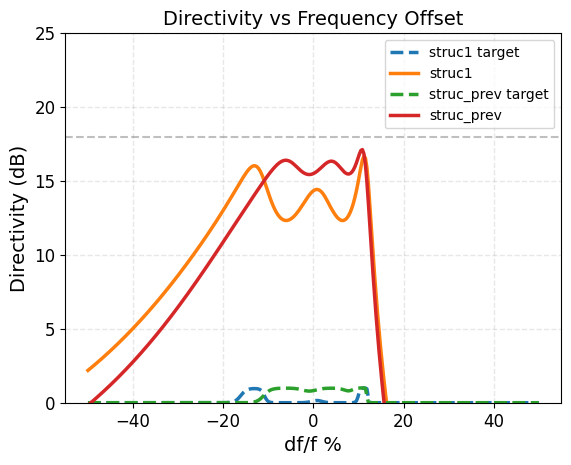

In [18]:
alpha1 = np.array([3, -1.2, 2.9, -1.2, 1])*1.4
beta1 = np.array([2.8, 0.75, 0.65, 0.6, 0.5])
alpha_prev = [ 6.99999966, -1.71747606,  5.99983892, -1.51878485,  1.25619562]
beta_prev = [2.79551947, 0.83206359, 0.57820422, 0.61651286, 0.53884595]
structure1 = LayeredStructure(alpha1, beta=beta1)
structure_prev = LayeredStructure(alpha_prev, beta_prev)
dir_prev = 10*np.log10(structure_prev.directivity(df))
dir_prev_tar = sigma(dir_prev, thres=15, k = 3)
dir1 = 10*np.log10(structure1.directivity(df))
dir1_tar = sigma(dir1, thres=15, k=3)
fig, ax = plt.subplots()
pl = Plotter(ax, st)
pl.plot(df*100, dir1_tar, label='struc1 target', linestyle='--')
pl.plot(df*100, dir1, label='struc1')
pl.plot(df*100, dir_prev_tar, label='struc_prev target', linestyle='--')
pl.plot(df*100, dir_prev, label='struc_prev')
pl.set_xlabel('df/f %')
pl.set_ylabel('Directivity (dB)')
pl.set_title('Directivity vs Frequency Offset')
pl.set_ylim((0, 25))
pl.finalize()
ax.axhline(18, color='gray', linestyle='--', alpha=0.5)
plt.show()
#alpha_prev = alpha1
#beta_prev = beta1